In [62]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns
matplotlib_font_size=7
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_search_result"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [63]:
query_size=100
ion_mode=[-1,1]


In [64]:
# parse txt
df=[]
data_rows=[]
for charge in ion_mode:
    search_result_file=path_benchmark_data/f'compare_search_result_query_{query_size}_charge_{charge}.txt'
    
    current_row=[]
    with open(search_result_file, 'r') as f:
        for line in f.readlines():
            items=line.split(":", maxsplit=1)
            key, value=items
            key=key.strip()
            value=value.strip()
            if key=="query_scan":
                if current_row and 'query_scan' in current_row:
                        data_rows.append(current_row)
                
                current_row={'charge':charge, 'query_scan':int(value)}
            elif key[-8:]=='max_diff':
                current_row[key]=float(value)
            else:
                continue

        if current_row and 'query_scan' in current_row:
            data_rows.append(current_row)

df = pd.DataFrame(data_rows)
df

,charge,query_scan,open_search_dynamic_all_build_max_diff,open_search_dynamic_build_update_1_max_diff,open_search_dynamic_build_update_2_max_diff,neutral_loss_search_dynamic_all_build_max_diff,neutral_loss_search_dynamic_build_update_1_max_diff,neutral_loss_search_dynamic_build_update_2_max_diff,hybrid_search_dynamic_all_build_max_diff,hybrid_search_dynamic_build_update_1_max_diff,hybrid_search_dynamic_build_update_2_max_diff
0,-1,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
2,-1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3,-1,1,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,-1,1,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
595,1,98,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
596,1,98,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
597,1,99,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
598,1,99,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN


In [65]:
def plot_compare_search_result_max_diff(
        df,
        search_type,
        ylim,
        save_path
):

    construction_types = [
        f"{search_type}_search_dynamic_all_build_max_diff",
        f"{search_type}_search_dynamic_build_update_1_max_diff",
        f"{search_type}_search_dynamic_build_update_2_max_diff"
    ]
    

    type_labels = {
        f"{search_type}_search_dynamic_all_build_max_diff": 'One-step build (1M)',
        f"{search_type}_search_dynamic_build_update_1_max_diff": 'Initial 100K + \n1 × 900K update',
        f"{search_type}_search_dynamic_build_update_2_max_diff": 'Initial 100K + \n9 × 100K updates'
    }

    df_data = df[construction_types + ['charge']]
    

    df_melted = df_data.melt(id_vars=["charge"], var_name="construction_type", value_name="max_diff")
    

    # fig, axes = plt.subplots(1, 3, figsize=(4.2, 2.2), width_ratios=[1.2,1.2,1.2], sharex=False, sharey=True)
    fig, axes = plt.subplots(1, 3, figsize=(3.6,2.4), 
                            #  width_ratios=[1.2,1.2,1.2], 
                             sharex=False, sharey=True)

    # my_color_palette = sns.color_palette("Set3", 12)

    charge_colors = {-1: "#66BC98", 1:"#FCD470"}
    charge_labels = {-1: '(-) ESI', 1: '(+) ESI'}
    

    for idx, const_type in enumerate(construction_types):
        ax = axes[idx]
        
  
        df_current = df_melted[df_melted['construction_type'] == const_type]
        
        sns.boxplot(data=df_current, x='charge', y='max_diff', 
                   palette=charge_colors, ax=ax, hue='charge', linewidth=0.4, width=0.6, fliersize=0, legend=False)
        sns.stripplot(data=df_current, x='charge', y='max_diff', 
                     palette=charge_colors, ax=ax, hue='charge', dodge=False, jitter=0.25, size=2, alpha=0.5, linewidth=0, legend=False)
        
        ax.set_title(type_labels[const_type], fontsize=matplotlib_font_size, )
        ax.set_ylabel('Maximum difference' if idx == 0 else '', fontsize=matplotlib_font_size, )
        
        ax.set_xlabel('')
        label_mapping = {
            -1: '(-) ESI',
            1: '(+) ESI'
        }
        unique_charges = sorted(df_current['charge'].unique(), key=lambda x: int(x))
        ax.set_xticks(range(len(unique_charges)))
        custom_labels = [label_mapping.get(int(charge), charge) for charge in unique_charges]
        ax.set_xticklabels(custom_labels, fontsize=matplotlib_font_size, )
        ax.yaxis.set_tick_params(labelsize=matplotlib_font_size,)

        ax.tick_params(which="both", width=0.4) 
        bottom=ylim[0]
        top=ylim[1]
        ax.set_ylim(bottom=bottom, top=top)
        for spine in ax.spines.values():  
            spine.set_linewidth(0.4)
        ax.grid(True, which="both", axis="y", ls="-", alpha=0.5, linewidth=0.3)

    fig.suptitle(f'Difference in similarity scores ({search_type.replace("_", " ")} search)', 
                 fontsize=matplotlib_font_size, x=0.5, y=0.93)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)
    plt.show()


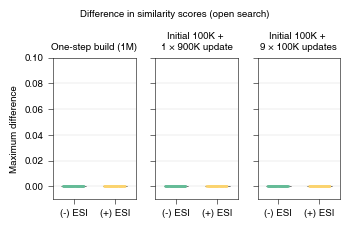

In [66]:

ylim=(-0.01,0.1)
search_type='open'
save_path=path_figures / f"compare_search_result_max_diff_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    ylim=ylim,
    save_path=save_path
)

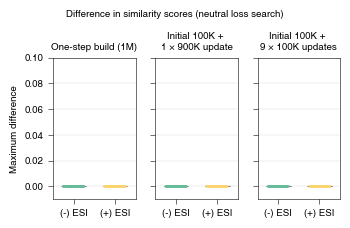

In [67]:
ylim=(-0.01,0.1)
search_type='neutral_loss'
save_path=path_figures / f"compare_search_result_max_diff_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    ylim=ylim,
    save_path=save_path
)

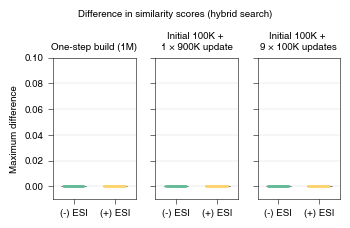

In [68]:

ylim=(-0.01,0.1)
search_type='hybrid'
save_path=path_figures / f"compare_search_result_max_diff_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    ylim=ylim,
    save_path=save_path
)